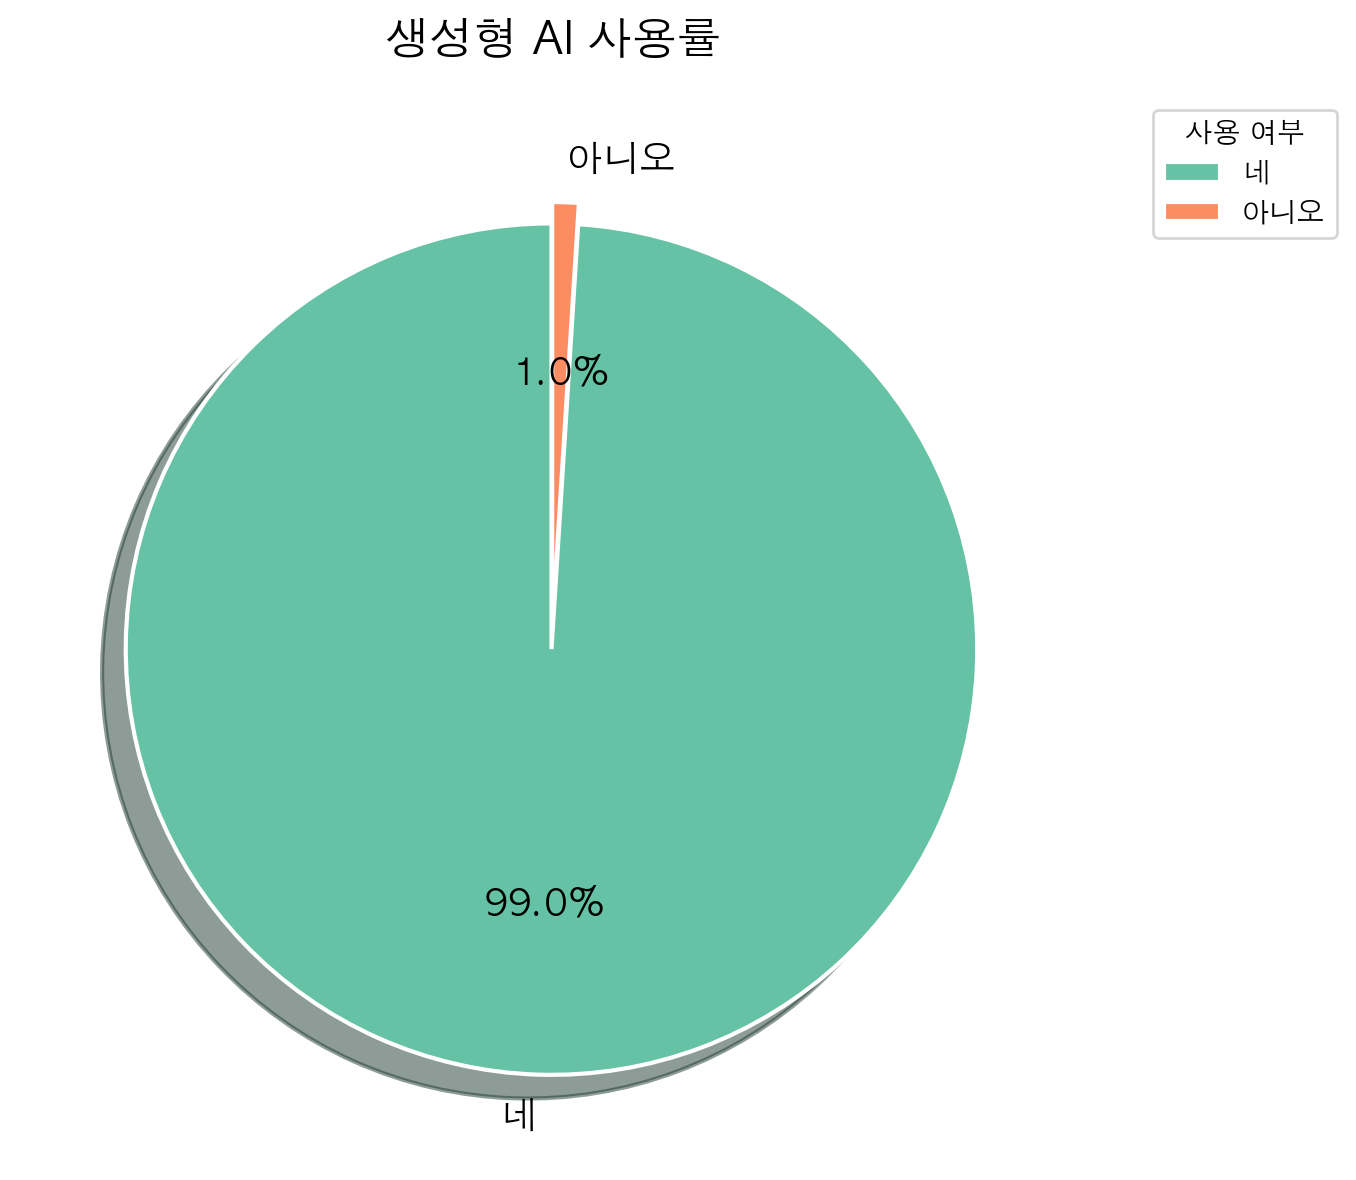

/var/folders/b_/2xj8qk5s5bz6vlr4ktwgxrk40000gn/T/ipykernel_91177/2924876268.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='사용 여부', loc='upper right')


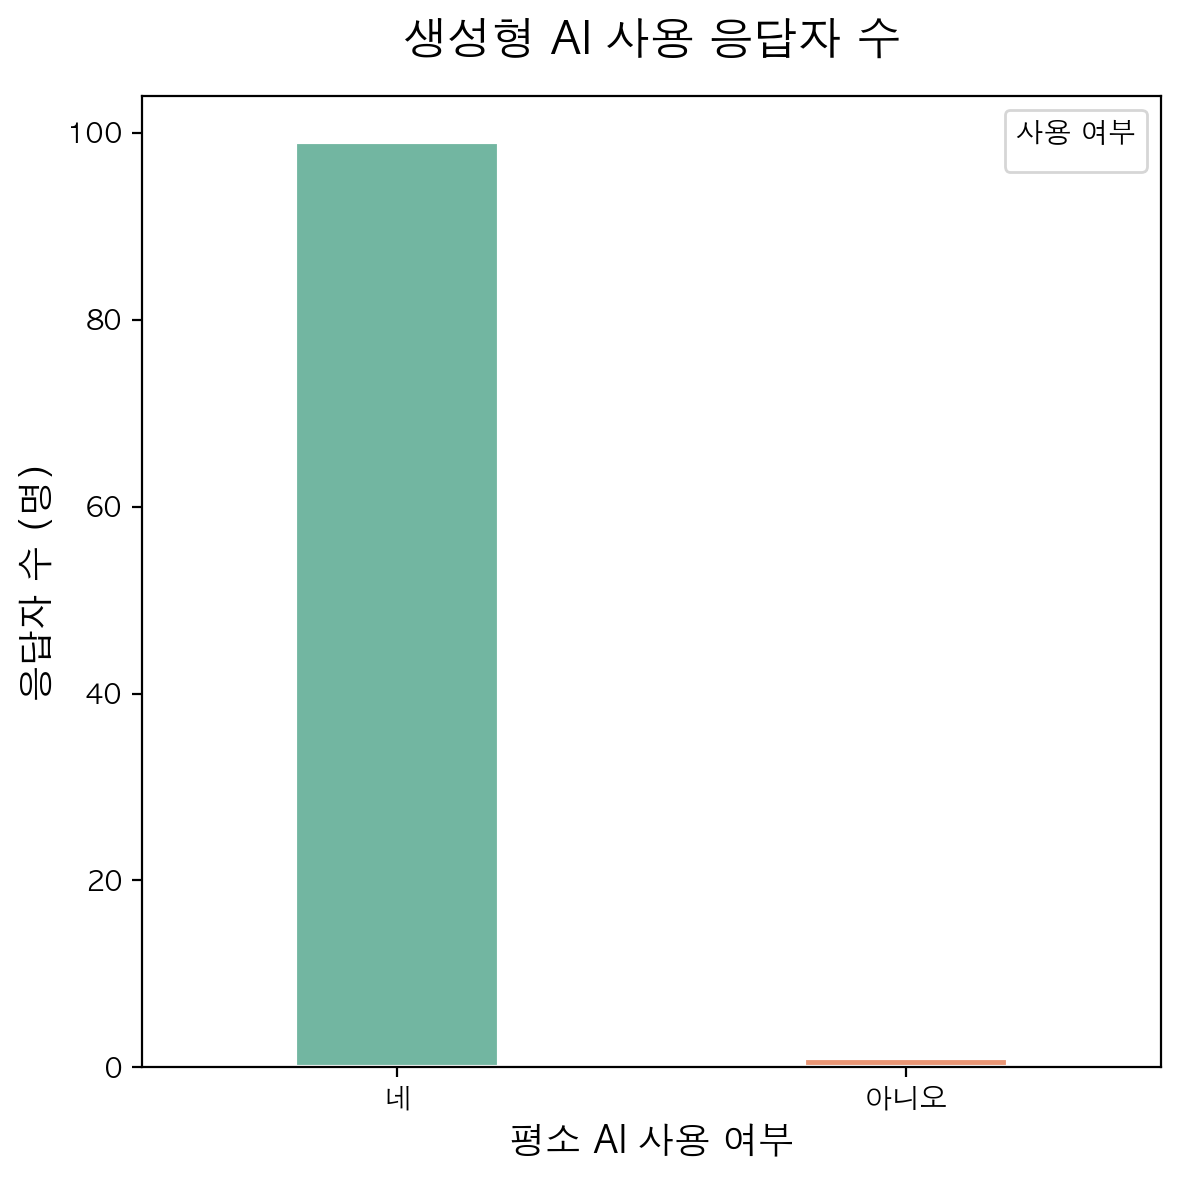

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
if platform.system() == 'Darwin':  # Mac OS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # Windows
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 고해상도 그래프 설정 (Jupyter Notebook 전용)
%config InlineBackend.figure_format = 'retina'

# 2. 데이터 불러오기
df = pd.read_csv('생성형 AI 사용 수요조사.csv')

# 3. AI 사용률 데이터 집계
usage_counts = df['평소에 AI를 사용하시나요?(*)'].value_counts()
labels = usage_counts.index
sizes = usage_counts.values

# 세련된 색상 팔레트 설정 (Set2)
custom_colors = sns.color_palette("Set2")

# ==========================================
# --- [첫 번째 그래프: 파이 차트 (단독 출력)] ---
# ==========================================
plt.figure(figsize=(7, 6))

# 첫 번째 조각(네)을 살짝 띄우기
explode = [0.05 if i == 0 else 0 for i in range(len(labels))] 

# pie 차트 생성 (흰색 테두리선을 추가하여 더 깔끔하게 디자인)
plt.pie(sizes, labels=labels, colors=custom_colors, autopct='%1.1f%%', 
        startangle=90, explode=explode, shadow=True, 
        textprops={'fontsize': 13}, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title('생성형 AI 사용률', fontsize=16, pad=15)
plt.legend(labels, title='사용 여부', loc='upper right', bbox_to_anchor=(1.25, 1))

plt.tight_layout()
plt.show() # 첫 번째 그래프 출력 완료


# ==========================================
# --- [두 번째 그래프: 바 차트 (단독 출력)] ---
# ==========================================
plt.figure(figsize=(6, 6)) # 전체 그래프 너비를 줄여서 막대가 뚱뚱해지는 것을 1차 방지

# Seaborn barplot (width 파라미터로 막대 두께를 얇게 조절: 0.4)
ax = sns.barplot(x=labels, y=sizes, palette="Set2", hue=labels, dodge=False, width=0.4)

plt.title('생성형 AI 사용 응답자 수', fontsize=16, pad=15)
plt.xlabel('평소 AI 사용 여부', fontsize=13)
plt.ylabel('응답자 수 (명)', fontsize=13)

# 막대에 흰색 테두리를 추가하여 파이차트와 디자인 통일감 부여
for patch in ax.patches:
    patch.set_edgecolor('white')
    patch.set_linewidth(1.5)

plt.legend(title='사용 여부', loc='upper right')

plt.tight_layout()
plt.show() # 두 번째 그래프 출력 완료